<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Patricia González Todd

En este trabajo buscamos analizar un fenómeno clásico de la DFT, el leakage o desparramo espectral. El objetivo es analizar cómo la relación entre la frecuencia de la señal $f_0$ y la resolución espectral del sistema $\Delta f$ afecta la visualización en el dominio de la frecuencia.  Adicionalmemte trabajaremos la técnica de zero padding la cuál ayudará mejorar la resolución de visualización del espectro.

La  **resolución espectral** ($\Delta f$) está determinada por la frecuencia de muestreo ($f_s$) 
y la cantidad de muestras ($N$):
$$\Delta f = \frac{f_s}{N}$$
Esta resolución determina el tamaño de los bins en el dominio de la frecuencia, es decir el espaciado mínimo en la grilla de muestras de una DFT o FFT.

 En esta experiencia tomaremos tres ejemplos de $f_0$ para visualizar que pasa si se ve afectadasu relación con $\Delta f$.
 $$ f_0 = k[  ] · \Delta f $$  Donde $k[  ]$ es un vector que me permitirá cambiar según el caso.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

# Parámetros
A = np.sqrt(2) #varianza normalizada
dc = 0
fs = 1000
fase = 0
muestras = 1000 
deltaf = fs/muestras #RESOLUCION ESPECTRAL
k0 = [(muestras/4),(muestras/4) + 1/4, (muestras/4) + 1/2]

# f0 sera un multiplo de k0


### Señal sintanizada -> espectro ideal
Para formar una señal sintonizada en frecuencia buscaremos que la $f_0$ coincida con un **múltiplo entero** de $\Delta f$, trabajaremos con $k[0]$, de esta manera veremos un espectro de este estilo:


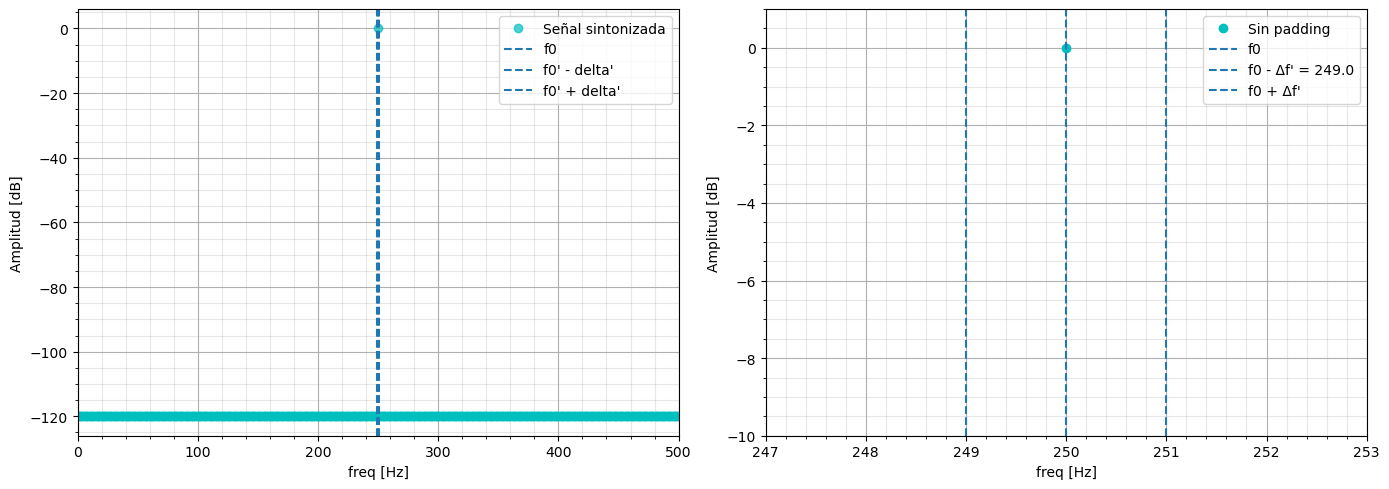

Verifico Parseval: Potencia de la señal = 1.0000000000000002 ~ 1.0000000000000002 = Potencia espectro
Se verifica potencia unitaria en ambos ✓ 


In [30]:
f0 = k0[0]*deltaf 

tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs) 

#S sintonizada
e_S = np.fft.fft(S)/(muestras)  # escalo para que me de donde yo quiero
mod_e_S = (np.abs(e_S)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
mod_e_S_db = 10*np.log10(mod_e_S + 1e-12) #db

ffreq = np.arange(0, muestras)*deltaf

# ===== figuras =====
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ================= gráfico completo =================

ax[0].plot(ffreq, mod_e_S_db,'co', label='Señal sintonizada', alpha=0.7)


ax[0].axvline(x=f0, linestyle='--', label='f0')
ax[0].axvline(x=(f0 - deltaf), linestyle = '--',label = "f0' - delta'")
ax[0].axvline(x=(f0 + deltaf), linestyle = '--',label = "f0' + delta'")

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'co', label='Sin padding', alpha=1)


ax[1].axvline(x=f0, linestyle='--', label='f0')
ax[1].axvline(x=f0 - deltaf, linestyle='--', label= f"f0 - Δf' = {f0 - deltaf}")
ax[1].axvline(x=f0 + deltaf, linestyle='--', label="f0 + Δf'")

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)
ax[1].set_ylim(-10, 1)


ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()


plt.tight_layout()
plt.show()

#verifico parseval SOLO LA MITAD 
potencia_freq = np.sum(mod_e_S[1:muestras//2])
'''
Debido a que la señal es real, su espectro posee simetría conjugada y
 la potencia se distribuye entre frecuencias positivas y negativas. 
Por ello, al considerar únicamente el semiespectro positivo, es necesario 
duplicar la potencia para recuperar la potencia total de la señal.
'''

muestras_periodo = int(fs/f0)
e_sen = np.abs(S)**2
energia_periodo = np.sum(e_sen[:muestras_periodo])

#La potencia promedio es:
potencia_sen = energia_periodo / muestras_periodo

print(f"Verifico Parseval: Potencia de la señal = {potencia_freq} ~ {potencia_sen} = Potencia espectro")
print("Se verifica potencia unitaria en ambos ✓ ")



Se puede evidenciar que la energia de la señal se concentra en el bin $k_0$ que corresponde a la frecuencia fundamental de la señal $f_0$

### La "Sinc" oculta

Una de las claves de esta experiencia es recordar que se cual sea la visualización del espectro, el verdadero fondo de éste siempre contiene una sinc en su interior debido a la multiplicación por una ventana de deltas unitarios que lleva a la convolucion en espectro con una sinc.
Al tomar un número finito de muestras ($N$), estamos multiplicando nuestra señal infinita por una **ventana rectangular** ($w[n]$). Por el teorema de convolución, esta multiplicación en el tiempo se traduce en una convolución en la frecuencia.

Para poder visualizar este espectro recurriremos a un método llamado **Zero-Padding**, este permitirá visualizar una mayor y mas concentrada cantidad de puntos.

**->** En el caso sintonizado ($f_0 = k \cdot \Delta f$), los bins de la DFT coinciden exactamente con el pico de la sinc y sus cruces por cero (nodos), ocultando la forma de la función transformada.

### Leakage
A partir de ahora trabajaremos con señales **desintonizada** y veremos gráficamente qué significa esto. En este caso trabajaremos con $k[1]$, lo que leva a tener una frecuencia $f_0$ que deja de ser múltiplo de la señal para pasar a tener una desintonización de $1/4· \Delta f$, de esta manera veremos un espectro de este estilo:

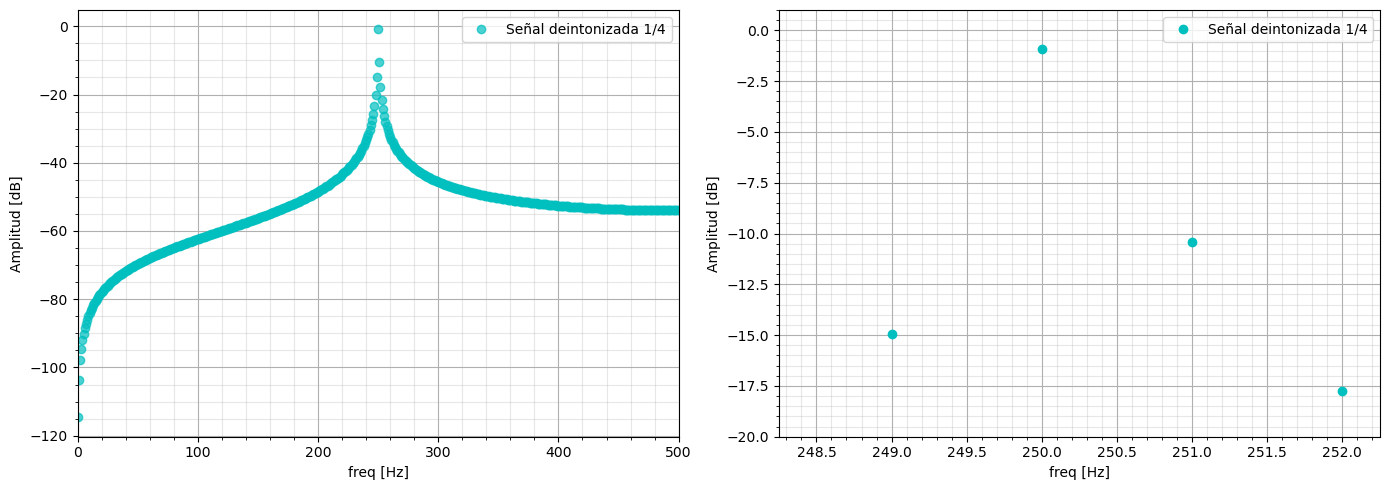

In [31]:
f0 = k0[1] * deltaf

# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras)

mod_e_S = (np.abs(e_S)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)

# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

# ===== figuras =====
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ================= gráfico completo =================

ax[0].plot(ffreq, mod_e_S_db,'co', label='Señal deintonizada 1/4', alpha=0.7)

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'co', label='Señal deintonizada 1/4', alpha=1)

#ax[1].axhline(y= np.max(mod_e_S_db), linestyle='--', label= f"f0 = {f0})

ax[1].set_xlim(f0 - 2*deltaf, f0 + 2*deltaf)
ax[1].set_ylim(-20, 1)
 
ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()

plt.tight_layout()
plt.show()


Mientras que con una desintonizaciòn de $1/2· \Delta f$, veremos un espectro de este estilo:

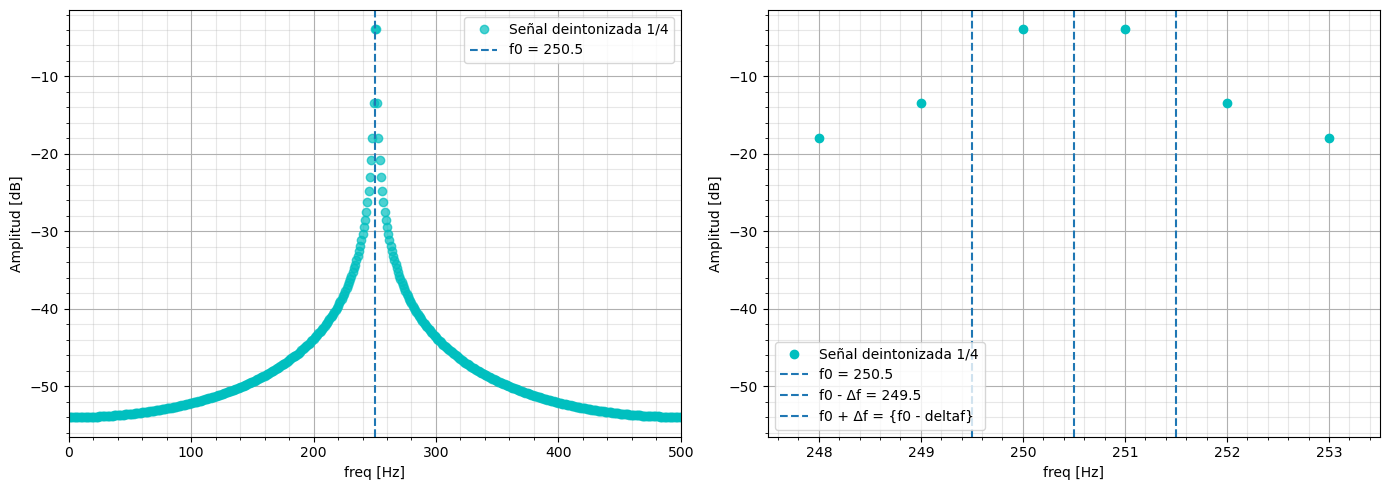

In [32]:
f0 = k0[2] * deltaf

# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras)

mod_e_S = (np.abs(e_S)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)

# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

# ===== figuras =====
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ================= gráfico completo =================

ax[0].plot(ffreq, mod_e_S_db,'co', label='Señal deintonizada 1/4', alpha=0.7)

ax[0].axvline(x=f0, linestyle='--', label=f"f0 = {f0}")

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'co', label='Señal deintonizada 1/4', alpha=1)

ax[1].axvline(x=f0, linestyle='--', label= f"f0 = {f0}")
ax[1].axvline(x=f0 - deltaf, linestyle='--', label= f"f0 - Δf = {f0 - deltaf}")
ax[1].axvline(x=f0 + deltaf, linestyle='--', label="f0 + Δf = {f0 - deltaf}")

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)

ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()

plt.tight_layout()
plt.show()



En los gráficos superiores se evidencia que, al desintonizar la señal, el espectro difiere por completo del caso ideal. Cuando la frecuencia de la señal es tal que:$$f_0 \neq k \cdot \Delta f \quad \forall k \in \mathbb{Z}$$la energía no puede concentrarse en un único bin. Este fenómeno, conocido como Spectral Leakage, ocurre porque la periodicidad de la señal no coincide con la ventana de observación.Sin embargo, el desparramo no es aleatorio. Lo que realmente estamos visualizando es la función sinc (resultado de la ventana rectangular en el tiempo) que ahora está "desalineada" respecto a nuestra rejilla de bins. En el caso sintonizado, los bins caían justo en los cruces por cero de la sinc, dándonos un "piso uniforme" de ceros. Al desintonizar, los bins comienzan a muestrear los lóbulos laterales de esa misma sinc, revelando esa estructura de energía distribuida que ya no permite identificar un único pico perfecto.

### Ejecución del zero-padding
El cero padding consiste en concatenar al vector de muestras un vector lo suficientemente grande de ceros, lo que permite definir un tamaño mayor de de muestras ficticio  y así llegar a:
* **Interpolar el espectro:** Aumentar la densidad de muestras en frecuencia ($\Delta f_p < \Delta f$) para suavizar la visualización.
* **Mitigar el error de amplitud:** Al tener más puntos, es más probable que uno de los bins se ubique cerca del máximo real del lóbulo principal.
* **Análisis de la ventana:** Visualizar con mayor definición la estructura del lóbulo principal y los lóbulos laterales impuestos por el truncamiento temporal de la señal.

Esta técnica es muy útil al enfrentarse a un leakege ya que permite visualizar el verdadero espectro.

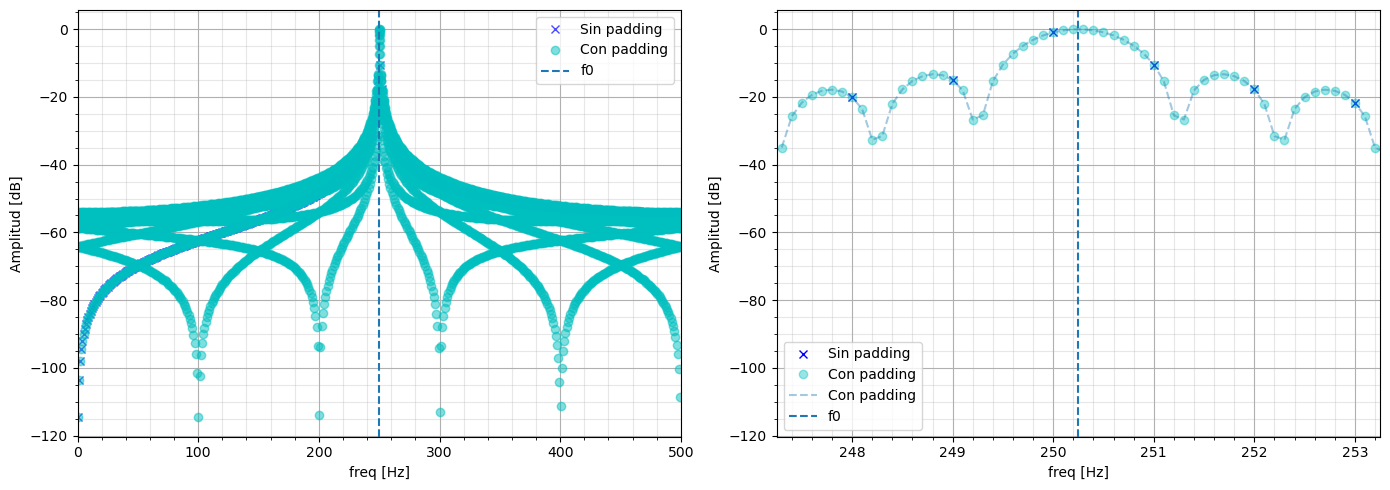

Verifico Parseval: Potencia de la señal = 1.0000074021728604 ~ 0.9989979968534691 = Potencia espectro
Se verifica potencia unitaria en ambos ✓ 

--- CORRECCIÓN DE ÍNDICES EN SEMIESPECTRO ---
Potencia Tiempo:             0.999000
Potencia Semiespectro:       0.999000
Diferencia Semiespectro:     3.33e-16


In [33]:
f0 = k0[1] * deltaf

# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras)

mod_e_S = (np.abs(e_S)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)

# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

# ===== zero padding =====
ceros = np.zeros(9*1000)

S_p = np.concatenate([S, ceros])

muestrasp = len(S_p) #deberia ser 10000 ahora

deltafp = fs / muestrasp

# ===== FFT padding =====
e_Sp = np.fft.fft(S_p) / (muestrasp)

mod_e_Sp = (np.abs(e_Sp)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado


# tengo que escalar el espectro nuevamente para que vuelva a estar normalizado
#cada espectro esta dividido por muestras, al cuadrado y duplicado
#agrego un factor de escala que me devuelva esa deferencia que hay entre cada una
# la division entre muestras me da que multiplo de muesttras agregue, 
# luego al cuadrado para conservar ese modulo 
#no duplico porque no necesito corregir simetrias
escalado =((muestrasp/ muestras)**2)

mod_e_Sp_norm = mod_e_Sp*escalado

mod_e_Sp_db = 10 * np.log10(mod_e_Sp_norm + 1e-12)


# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

ffreq_p = np.arange(0, muestrasp) * deltafp


# ===== figuras =====o|
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# ================= gráfico completo =================

ax[0].plot(ffreq,
           mod_e_S_db,'bx', label='Sin padding', alpha=0.7)

ax[0].plot(ffreq_p,
           mod_e_Sp_db,'co', label='Con padding', alpha=0.5)

ax[0].axvline(x=f0, linestyle='--', label='f0')

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'bx', label='Sin padding', alpha=1)

ax[1].plot(ffreq_p, mod_e_Sp_db, 'co', label='Con padding',  alpha=0.4)
ax[1].plot(ffreq_p, mod_e_Sp_db, '--', label='Con padding',  alpha=0.4)


ax[1].axvline(x=f0, linestyle='--', label='f0')

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)

ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()


plt.tight_layout()
plt.show()


#verifico parseval SOLO LA MITAD 

potencia_freq = np.sum(mod_e_S[1:muestras//2])

'''
Debido a que la señal es real, su espectro posee simetría conjugada y
 la potencia se distribuye entre frecuencias positivas y negativas. 
Por ello, al considerar únicamente el semiespectro positivo, es necesario 
duplicar la potencia para recuperar la potencia total de la señal.
'''

muestras_periodo = int(fs/f0)
e_sen = np.abs(S)**2
energia_periodo = np.sum(e_sen[:muestras_periodo])

#La potencia promedio es:
potencia_sen = energia_periodo / 2 #VEO SOLO LA MITAD

print(f"Verifico Parseval: Potencia de la señal = {potencia_sen} ~ {potencia_freq} = Potencia espectro")
print("Se verifica potencia unitaria en ambos ✓ ")

# ==========================================
# VERIFICACIÓN DE PARSEVAL 
# ==========================================

# Potencia en el tiempo (promedio de toda la señal)
potencia_tiempo_completa = np.sum(np.abs(S)**2)/muestras

N = muestras

# Extraemos la potencia DC real (deshaciendo el *2 que tenía mod_e_S)
pot_DC = mod_e_S[0] / 2

# Sumamos las frecuencias positivas que ya están multiplicadas por 2
# Nota el "+ 1" en el límite superior para INCLUIR el bin N//2 - 1
pot_positivas = np.sum(mod_e_S[1 : N//2]) 

# Extraemos Nyquist real (deshaciendo el *2 que tenía mod_e_S)
# Nyquist solo existe si N es par
pot_nyquist = (mod_e_S[N//2] / 2) if N % 2 == 0 else 0

potencia_freq_semiespectro = pot_DC + pot_positivas + pot_nyquist

print("\n--- CORRECCIÓN DE ÍNDICES EN SEMIESPECTRO ---")
print(f"Potencia Tiempo:             {potencia_tiempo_completa:.6f}")
print(f"Potencia Semiespectro:       {potencia_freq_semiespectro:.6f}")
print(f"Diferencia Semiespectro:     {abs(potencia_tiempo_completa - potencia_freq_semiespectro):.2e}")

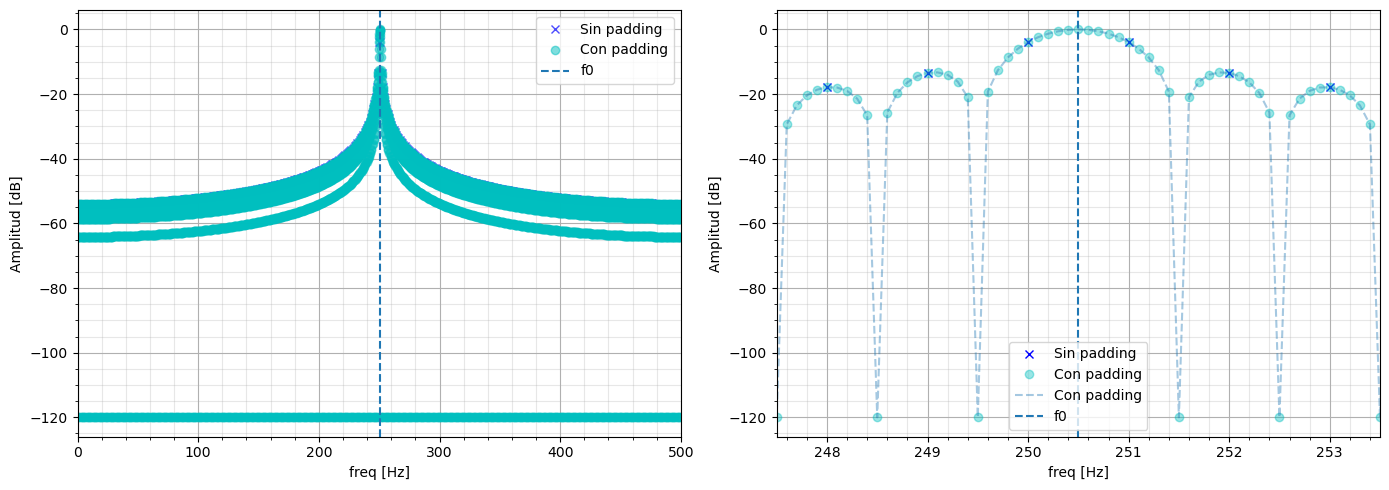

Verifico Parseval: Potencia de la señal = 1.0000296083261606 ~ 0.9999959999210432 = Potencia espectro
Se verifica potencia unitaria en ambos ✓ 

--- CORRECCIÓN DE ÍNDICES EN SEMIESPECTRO ---
Potencia Tiempo:             1.000000
Potencia Semiespectro:       1.000000
Diferencia Semiespectro:     0.00e+00


In [34]:
f0 = k0[2] * deltaf

# señal original
tt, S = mi_funcion_sen(A, dc, f0, fase, muestras, fs)


# ===== FFT original =====
e_S = np.fft.fft(S) / (muestras)

mod_e_S = (np.abs(e_S)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

mod_e_S_db = 10 * np.log10(mod_e_S + 1e-12)

# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

# ===== zero padding =====
ceros = np.zeros(9*1000)

S_p = np.concatenate([S, ceros])

muestrasp = len(S_p) #deberia ser 10000 ahora

deltafp = fs / muestrasp

# ===== FFT padding =====
e_Sp = np.fft.fft(S_p) / (muestrasp)

mod_e_Sp = (np.abs(e_Sp)**2)*2 #me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado


# tengo que escalar el espectro nuevamente para que vuelva a estar normalizado
#cada espectro esta dividido por muestras, al cuadrado y duplicado
#agrego un factor de escala que me devuelva esa deferencia que hay entre cada una
# la division entre muestras me da que multiplo de muesttras agregue, 
# luego al cuadrado para conservar ese modulo 
#no duplico porque no necesito corregir simetrias
escalado =((muestrasp/ muestras)**2)

mod_e_Sp_norm = mod_e_Sp*escalado

mod_e_Sp_db = 10 * np.log10(mod_e_Sp_norm + 1e-12)


# ejes de frecuencia
ffreq = np.arange(0, muestras) * deltaf

ffreq_p = np.arange(0, muestrasp) * deltafp


# ===== figuras =====o|
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# ================= gráfico completo =================

ax[0].plot(ffreq,
           mod_e_S_db,'bx', label='Sin padding', alpha=0.7)

ax[0].plot(ffreq_p,
           mod_e_Sp_db,'co', label='Con padding', alpha=0.5)

ax[0].axvline(x=f0, linestyle='--', label='f0')

ax[0].set_xlim(0, fs/2)

ax[0].set_xlabel("freq [Hz]")
ax[0].set_ylabel("Amplitud [dB]")

ax[0].minorticks_on()

ax[0].grid(True, which='major')
ax[0].grid(True, which='minor', alpha=0.3)

ax[0].legend()


# ================= zoom =================

ax[1].plot(ffreq, mod_e_S_db, 'bx', label='Sin padding', alpha=1)

ax[1].plot(ffreq_p, mod_e_Sp_db, 'co', label='Con padding',  alpha=0.4)
ax[1].plot(ffreq_p, mod_e_Sp_db, '--', label='Con padding',  alpha=0.4)


ax[1].axvline(x=f0, linestyle='--', label='f0')

ax[1].set_xlim(f0 - 3*deltaf, f0 + 3*deltaf)

ax[1].set_xlabel("freq [Hz]")
ax[1].set_ylabel("Amplitud [dB]")

ax[1].minorticks_on()

ax[1].grid(True, which='major')
ax[1].grid(True, which='minor', alpha=0.3)

ax[1].legend()


plt.tight_layout()
plt.show()


#verifico parseval SOLO LA MITAD 

potencia_freq = np.sum(mod_e_S[1:muestras//2])

'''
Debido a que la señal es real, su espectro posee simetría conjugada y
 la potencia se distribuye entre frecuencias positivas y negativas. 
Por ello, al considerar únicamente el semiespectro positivo, es necesario 
duplicar la potencia para recuperar la potencia total de la señal.
'''

muestras_periodo = int(fs/f0)
e_sen = np.abs(S)**2
energia_periodo = np.sum(e_sen[:muestras_periodo])

#La potencia promedio es:
potencia_sen = energia_periodo / 2 #VEO SOLO LA MITAD

print(f"Verifico Parseval: Potencia de la señal = {potencia_sen} ~ {potencia_freq} = Potencia espectro")
print("Se verifica potencia unitaria en ambos ✓ ")

# ==========================================
# VERIFICACIÓN DE PARSEVAL 
# ==========================================

# Potencia en el tiempo (promedio de toda la señal)
potencia_tiempo_completa = np.sum(np.abs(S)**2)/muestras

N = muestras

# Extraemos la potencia DC real (deshaciendo el *2 que tenía mod_e_S)
pot_DC = mod_e_S[0] / 2

# Sumamos las frecuencias positivas que ya están multiplicadas por 2
# Nota el "+ 1" en el límite superior para INCLUIR el bin N//2 - 1
pot_positivas = np.sum(mod_e_S[1 : N//2]) 

# Extraemos Nyquist real (deshaciendo el *2 que tenía mod_e_S)
# Nyquist solo existe si N es par
pot_nyquist = (mod_e_S[N//2] / 2) if N % 2 == 0 else 0

potencia_freq_semiespectro = pot_DC + pot_positivas + pot_nyquist

print("\n--- CORRECCIÓN DE ÍNDICES EN SEMIESPECTRO ---")
print(f"Potencia Tiempo:             {potencia_tiempo_completa:.6f}")
print(f"Potencia Semiespectro:       {potencia_freq_semiespectro:.6f}")
print(f"Diferencia Semiespectro:     {abs(potencia_tiempo_completa - potencia_freq_semiespectro):.2e}")

ahora desintinozacion 1/2

La aplicar en cada uno de padding que lleva a un $N_p = 10000$ se puede evidenciar un expectro mucho más suave donde se percibe claramente el módulo de una sinc. Adicionalmente se puede terminar de cerrar el concepto de leakage, donde al desintonizar la muestras caen en distintos valores de la sinc, lo que lleva a visualizar espectro del todo distinto